In [428]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from datetime import datetime, timedelta

In [429]:
def generate_dirty_minecraft_data():
    np.random.seed(42)
    random.seed(42)

    # 1. USERS
    n_users = 3000
    user_ids = np.arange(1000, 1000 + n_users)
    reg_dates = [datetime(2023, 1, 1) + timedelta(days=np.random.randint(0, 90),
                                                 hours=np.random.randint(0, 24)) for _ in range(n_users)]

    versions = ['1.19.4', '1.20.1', '1.18.2', None, '1.20.2']
    client_version = [random.choice(versions) for _ in range(n_users)]
    is_premium = np.random.choice([True, False], size=n_users, p=[0.3, 0.7])

    users_df = pd.DataFrame({
        'user_id': user_ids,
        'registration_date': reg_dates,
        'client_version': client_version,
        'is_premium': is_premium
    })

    users_df = pd.concat([users_df, users_df.sample(50)]).reset_index(drop=True)

    n_sessions = 25000
    session_user_ids = np.random.choice(user_ids, size=n_sessions)

    login_times = []
    logout_times = []
    realms = []

    realm_choices = ['Survival', 'Anarchy', 'MiniGames']
    dirty_realms = ['survival', 'SURVIVAL', 'surv', 'Anarchy', 'anarchy', 'MiniGames', 'minigames', 'mini_games']

    for uid in session_user_ids:
        user_reg = users_df[users_df['user_id'] == uid]['registration_date'].iloc[0]
        max_days = (datetime(2023, 3, 31) - user_reg).days
        if max_days <= 0: max_days = 1

        login = user_reg + timedelta(days=random.randint(0, max_days), hours=random.randint(0, 23), minutes=random.randint(0, 59))
        duration_minutes = max(1, int(np.random.exponential(scale=45)))
        logout = login + timedelta(minutes=duration_minutes)

        login_times.append(login)
        logout_times.append(logout)
        realms.append(random.choice(dirty_realms))

    sessions_df = pd.DataFrame({
        'session_id': np.arange(1, n_sessions + 1),
        'user_id': session_user_ids,
        'login_time': login_times,
        'logout_time': logout_times,
        'server_realm': realms
    })

    dirty_indices = np.random.choice(sessions_df.index, size=100, replace=False)
    for idx in dirty_indices:
        sessions_df.at[idx, 'logout_time'] = sessions_df.at[idx, 'login_time'] - timedelta(minutes=random.randint(10, 60))

    dirty_date_indices = np.random.choice(sessions_df.index, size=50, replace=False)
    for idx in dirty_date_indices:
        sessions_df.at[idx, 'login_time'] = datetime(1970, 1, 1)
        sessions_df.at[idx, 'logout_time'] = datetime(1970, 1, 1) + timedelta(minutes=30)

    users_df.to_csv('users.csv', index=False)
    sessions_df.to_csv('sessions.csv', index=False)
    print("Файлы users.csv и sessions.csv успешно сгенерированы!")

generate_dirty_minecraft_data()

Файлы users.csv и sessions.csv успешно сгенерированы!


In [430]:
sessions = pd.read_csv('/content/sessions.csv')
users = pd.read_csv('/content/users.csv')

Очистка данных

In [431]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   session_id    25000 non-null  int64 
 1   user_id       25000 non-null  int64 
 2   login_time    25000 non-null  object
 3   logout_time   25000 non-null  object
 4   server_realm  25000 non-null  object
dtypes: int64(2), object(3)
memory usage: 976.7+ KB


In [432]:
sessions.head(5)

,session_id,user_id,login_time,logout_time,server_realm
0,1,1184,2023-03-29 20:20:00,2023-03-29 20:35:00,SURVIVAL
1,2,2764,2023-03-29 05:07:00,2023-03-29 05:30:00,surv
2,3,1900,2023-03-28 05:09:00,2023-03-28 06:41:00,minigames
3,4,1220,2023-03-17 17:08:00,2023-03-17 17:54:00,minigames
4,5,2467,2023-03-22 14:31:00,2023-03-22 14:51:00,surv


In [433]:
map_servers = {
    'surv':'survival',
    'mini_games': 'minigames',
}

sessions['login_time'] = pd.to_datetime(sessions['login_time'])
sessions['logout_time'] = pd.to_datetime(sessions['logout_time'])
sessions['server_realm'] = sessions['server_realm'].str.strip().str.lower().replace(map_servers)

In [434]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3050 entries, 0 to 3049
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            3050 non-null   int64 
 1   registration_date  3050 non-null   object
 2   client_version     2416 non-null   object
 3   is_premium         3050 non-null   bool  
dtypes: bool(1), int64(1), object(2)
memory usage: 74.6+ KB


In [435]:
users['registration_date'] = pd.to_datetime(users['registration_date'])
users['client_version'] = users['client_version'].fillna('Unknown')

In [436]:
sessions = sessions[sessions['login_time'].between('2022-01-01', '2023-03-31')]
# sessions['login_time'].sort_values(ascending=True).head(20)

# sessions['logout_time'].sort_values(ascending=True).head(5)
print(sessions.shape)
sessions = sessions.query('login_time < logout_time')
print(sessions.shape)

(23895, 5)
(23800, 5)


In [437]:
users['registration_date'].sort_values(ascending=False).head(10)

,registration_date
846,2023-03-31 23:00:00
733,2023-03-31 22:00:00
440,2023-03-31 22:00:00
2429,2023-03-31 22:00:00
1370,2023-03-31 21:00:00
2591,2023-03-31 20:00:00
219,2023-03-31 20:00:00
2208,2023-03-31 19:00:00
802,2023-03-31 17:00:00
2528,2023-03-31 16:00:00


In [438]:
sessions.duplicated().sum()
sessions = sessions.drop_duplicates()

users.duplicated().sum()
users = users.drop_duplicates()

**Расчет базовых метрик. Удержание и активность**

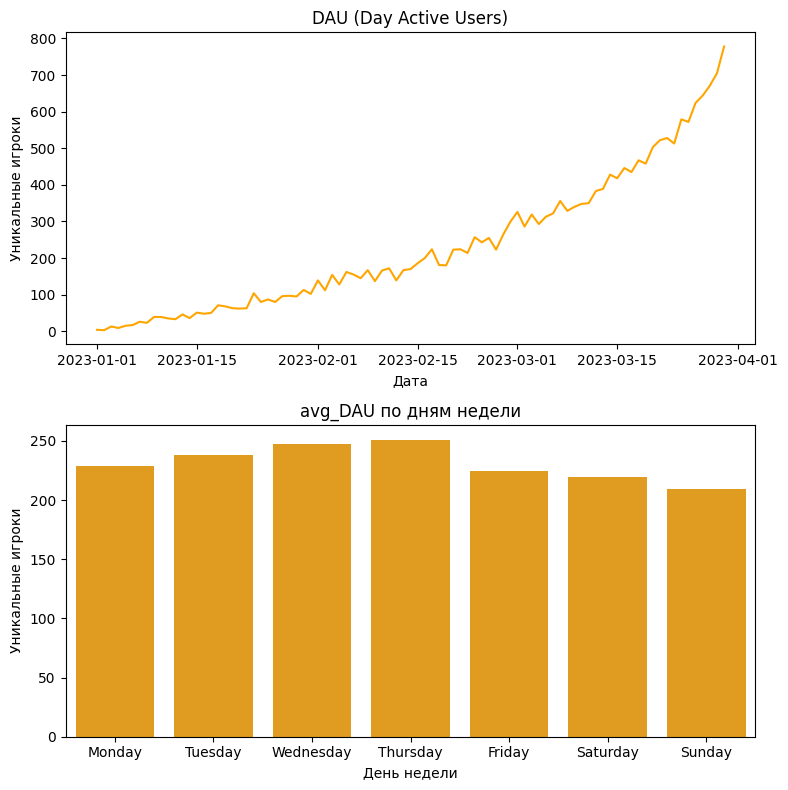

In [439]:
sessions['date'] = sessions['login_time'].dt.date
sessions['day_name'] = sessions['login_time'].dt.day_name()

DAU = (
    sessions.groupby(['date', 'day_name'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'DAU'})
)

DAU_day_name = (DAU.groupby('day_name')['DAU']
                .mean()
                .reset_index()
                .rename(columns={'user_id': 'avg_DAU'})
)

fig, ax = plt.subplots(2, 1, figsize=(8, 8))

sns.lineplot(
    data=DAU,
    x='date',
    y='DAU',
    color='orange',
    ax=ax[0]
)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.barplot(
    data=DAU_day_name,
    x='day_name',
    y='DAU',
    color='orange',
    ax=ax[1],
    order=day_order
)

ax[0].set_title('DAU (Day Active Users)')
ax[0].set_ylabel('Уникальные игроки')
ax[0].set_xlabel('Дата')

ax[1].set_title('avg_DAU по дням недели')
ax[1].set_ylabel('Уникальные игроки')
ax[1].set_xlabel('День недели')
plt.tight_layout()
plt.show()


In [440]:
sessions['week'] = sessions['login_time'].dt.isocalendar().week
sessions['month'] = sessions['login_time'].dt.month

WAU = (
    sessions.groupby('week')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'WAU'})
)

MAU = (
    sessions.groupby('month')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'MAU'})
)
DAU['date'] = pd.to_datetime(DAU['date'])
DAU['month'] = DAU['date'].dt.month
DAU_month = (
    DAU.groupby('month')['DAU']
    .mean()
    .reset_index()
    .round(2)
    .rename(columns={'DAU': 'DAU_avg_month'}))

DAU_MAU = DAU_month.merge(MAU, on='month', how='left')
DAU_MAU['sticky_factor'] = (DAU_MAU['DAU_avg_month'] / DAU_MAU['MAU'] * 100).round(2)

In [441]:
full_df = users.merge(sessions, on='user_id', how='inner')
full_df['lifetime'] = (full_df['login_time'] - full_df['registration_date']).dt.days
full_df['registration_week'] = full_df['registration_date'].dt.isocalendar().week

cohort_reg_week = (
    full_df.groupby('registration_week')['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'total_users'})
)

retention = (
    full_df.groupby(['registration_week', 'lifetime'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users_every_day_active'})
)

pivot_table = pd.pivot_table(
    data=retention,
    index='registration_week',
    columns='lifetime',
    values='users_every_day_active',
    aggfunc='sum'
).reset_index()

target_days = [1, 3, 7, 14]
filtered_pivot = pivot_table[target_days]

cohort_sizes = cohort_reg_week.set_index('registration_week')['total_users']

final_retention = (filtered_pivot.div(cohort_sizes, axis=0) * 100).round(2)
final_retention

lifetime,1,3,7,14
0,NaN,NaN,NaN,NaN
1,9.84,11.48,11.07,12.70
2,13.33,9.17,11.25,11.67
3,11.74,7.29,10.93,7.29
4,14.47,13.62,12.34,10.64
5,13.36,11.34,14.17,11.74
6,17.51,22.58,16.13,16.59
7,19.30,21.93,19.30,21.05
8,33.33,27.48,25.23,26.13
9,23.33,21.48,22.96,20.37


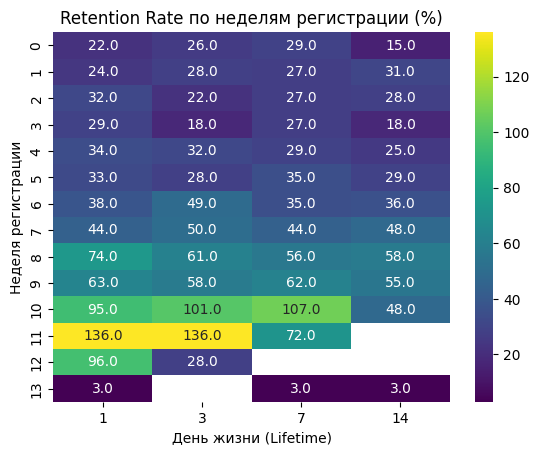

In [442]:
sns.heatmap(
    data=filtered_pivot,
    annot=True,
    fmt='.1f',
    cmap='viridis'
)
plt.title('Retention Rate по неделям регистрации (%)')
plt.ylabel('Неделя регистрации')
plt.xlabel('День жизни (Lifetime)')
plt.show()

Анализ денежной массы

In [443]:
def generate_economy_data():
    np.random.seed(42)
    random.seed(42)

    user_ids = np.arange(1000, 4000)
    n_transactions = 150000

    whales = set(np.random.choice(user_ids, size=int(len(user_ids)*0.05), replace=False))

    records = []
    start_date = datetime(2023, 1, 1)

    for _ in range(n_transactions):
        uid = random.choice(user_ids)
        is_whale = uid in whales

        t_date = start_date + timedelta(days=random.randint(0, 89),
                                        hours=random.randint(0,23),
                                        minutes=random.randint(0,59))

        action_choice = random.choices(
            ['faucet_mob', 'faucet_quest', 'sink_shop', 'sink_tax', 'p2p_trade'],
            weights=[0.45, 0.20, 0.15, 0.05, 0.15]
        )[0]

        amount = 0
        if action_choice in ['faucet_mob', 'faucet_quest']:
            amount = random.randint(10, 100) * (8 if is_whale else 1)
        elif action_choice in ['sink_shop', 'sink_tax']:
            amount = -random.randint(20, 150) * (5 if is_whale else 1)
        else:
            amount = random.randint(-500, 500) * (3 if is_whale else 1)

        records.append({'user_id': uid, 'action_type': action_choice, 'amount': amount, 'timestamp': t_date})

    df = pd.DataFrame(records)

    df.loc[df.sample(frac=0.02).index, 'action_type'] = np.nan
    bug_idx = df.sample(15).index
    df.loc[bug_idx, 'amount'] = 9999999
    bug_faucet_idx = df[df['action_type'] == 'faucet_mob'].sample(20).index
    df.loc[bug_faucet_idx, 'amount'] = -50

    df.sort_values('timestamp', inplace=True)
    df.to_csv('economy_logs.csv', index=False)
    print("Успех! Файл economy_logs.csv создан и готов к работе.")

generate_economy_data()

Успех! Файл economy_logs.csv создан и готов к работе.


Анализ денежной массы

In [444]:
economy = pd.read_csv('economy_logs.csv')
economy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   user_id      150000 non-null  int64 
 1   action_type  147000 non-null  object
 2   amount       150000 non-null  int64 
 3   timestamp    150000 non-null  object
dtypes: int64(2), object(2)
memory usage: 4.6+ MB


In [445]:
economy['action_type'] = economy['action_type'].fillna('Unknown')
economy['timestamp'] = pd.to_datetime(economy['timestamp'])
economy['date'] = economy['timestamp'].dt.date
economy.sort_values(by='amount', ascending=True).head(5)

,user_id,action_type,amount,timestamp,date
94639,2607,p2p_trade,-1500,2023-02-26 21:46:00,2023-02-26
35643,3254,p2p_trade,-1500,2023-01-22 10:20:00,2023-01-22
35083,2600,p2p_trade,-1497,2023-01-22 02:14:00,2023-01-22
63992,1289,p2p_trade,-1494,2023-02-08 08:01:00,2023-02-08
14690,2090,p2p_trade,-1491,2023-01-09 20:00:00,2023-01-09


In [446]:
economy = economy[economy['amount'] < 999_999]

faucets = economy[(economy['action_type'].isin(['faucet_mob', 'faucet_quest'])) & \
                  (economy['amount'] > 0)].copy()

faucets['date'] = faucets['timestamp'].dt.date

faucets_amount = (
    faucets.groupby('date')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
)

sinks = economy[economy['action_type'].isin(['sink_shop', 'sink_tax'])].copy()

sinks['amount'] = abs(sinks['amount'])

sinks_amount = (
    sinks.groupby('date')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
)

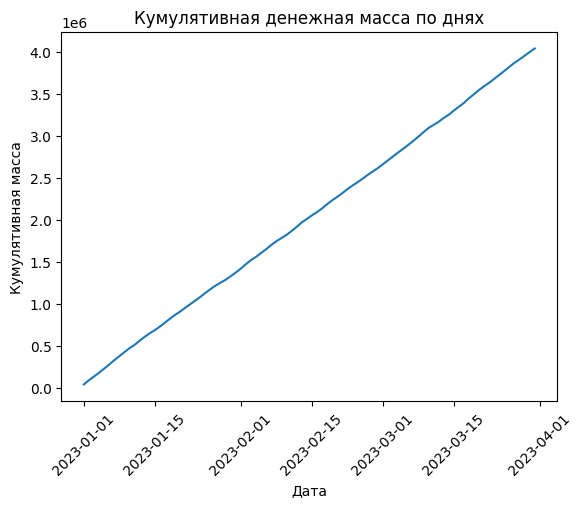

In [447]:
net_change = faucets_amount.merge(sinks_amount, on='date', how='inner')
net_change['net_change'] = net_change['total_amount_x'] - net_change['total_amount_y']
net_change['cum_sum'] = net_change['net_change'].cumsum()

sns.lineplot(
    data=net_change,
    x='date',
    y='cum_sum'
)
plt.xticks(rotation=45)
plt.title('Кумулятивная денежная масса по днях')
plt.xlabel('Дата')
plt.ylabel('Кумулятивная масса')
plt.show()

**Социальное неравенство (Распределение богатства)**

In [448]:
user_amount = (
    economy.groupby('user_id')['amount']
    .sum()
    .reset_index()
    .rename(columns={'amount': 'total_amount'})
    .sort_values(by='total_amount', ascending=False)
)

balance = user_amount['total_amount'].sum()
top_5_pct_users = user_amount.head(int(user_amount.shape[0] * 0.05) )
lower_50_pct_users = user_amount.tail(int(user_amount.shape[0] * 0.5))

top_5_wealth = top_5_pct_users['total_amount'].sum()
lower_50_wealth = lower_50_pct_users['total_amount'].sum()

top_5_share = (top_5_wealth / balance) * 100
lower_50_share = (lower_50_wealth / balance) * 100

print(f"Топ-5% богачей владеют: {top_5_share:.2f}% всей валюты")
print(f"Нижние 50% игроков владеют: {lower_50_share:.2f}% всей валюты")

Топ-5% богачей владеют: 35.24% всей валюты
Нижние 50% игроков владеют: 9.78% всей валюты


In [449]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

def generate_donations_data():
    np.random.seed(42)
    random.seed(42)

    user_ids = np.arange(1000, 4000)

    paying_users = np.random.choice(user_ids, size=int(len(user_ids)*0.09), replace=False)

    records = []
    start_date = datetime(2023, 1, 1)

    whales = set(np.random.choice(paying_users, size=int(len(paying_users)*0.15), replace=False))

    for uid in paying_users:
        is_whale = uid in whales
        num_purchases = random.randint(4, 10) if is_whale else random.randint(1, 2)

        for _ in range(num_purchases):
            t_date = start_date + timedelta(days=random.randint(0, 89),
                                            hours=random.randint(0,23))

            category = random.choices(
                ['VIP_status', 'Lootbox', 'InGame_Currency', 'Cosmetics'],
                weights=[0.3, 0.4, 0.2, 0.1]
            )[0]

            prices = {'VIP_status': 500, 'Lootbox': 150, 'InGame_Currency': 300, 'Cosmetics': 250}
            amount = prices[category] * (random.randint(2, 5) if is_whale and category != 'VIP_status' else 1)

            records.append({'payment_id': random.randint(100000, 999999),
                            'user_id': uid,
                            'amount_val': amount,
                            'item_category': category,
                            'timestamp': t_date})

    df = pd.DataFrame(records)

    refund_idx = df.sample(10).index
    df.loc[refund_idx, 'amount_val'] = -df.loc[refund_idx, 'amount_val']
    nan_idx = df.sample(frac=0.03).index
    df.loc[nan_idx, 'item_category'] = np.nan

    df.sort_values('timestamp', inplace=True)
    df.to_csv('donations.csv', index=False)
    print("Успех! Файл donations.csv создан.")

generate_donations_data()

Успех! Файл donations.csv создан.


In [450]:
donations = pd.read_csv('donations.csv')
donations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   payment_id     599 non-null    int64 
 1   user_id        599 non-null    int64 
 2   amount_val     599 non-null    int64 
 3   item_category  581 non-null    object
 4   timestamp      599 non-null    object
dtypes: int64(3), object(2)
memory usage: 23.5+ KB


In [451]:
donations['item_category'] = donations['item_category'].fillna('Unknown')
donations['timestamp'] = pd.to_datetime(donations['timestamp'])
donations = donations[donations['amount_val'] > 0]

In [452]:
CR = (donations['user_id'].unique().sum() / users['user_id'].unique().sum() * 100).round(2)
revenue = donations['amount_val'].sum()
ARPU = revenue / users['user_id'].nunique()
ARPPU = revenue / donations['user_id'].nunique()
LTV = (
    donations.groupby('user_id')['amount_val']
    .sum()
    .reset_index()
    .rename(columns={'amount_val': 'total_amount'})
)

print(f'Conversion Rate %users: {CR}')
print(f'Total revenue: {revenue}')
print(f'Average Revenue Users: {ARPU}')
print(f'Average Revenue Per Users: {ARPU}')
print(f'LifeTime Value: {LTV}')

Conversion Rate %users: 8.72
Total revenue: 264850
Average Revenue Users: 88.28333333333333
Average Revenue Per Users: 88.28333333333333
LifeTime Value:      user_id  total_amount
0       1000           150
1       1014           500
2       1032          6400
3       1044           150
4       1045           400
..       ...           ...
263     3909           250
264     3934           450
265     3967           500
266     3986          2000
267     3991           650

[268 rows x 2 columns]


Процент от общей выручки сервера принесли эти «Киты»: 60.69


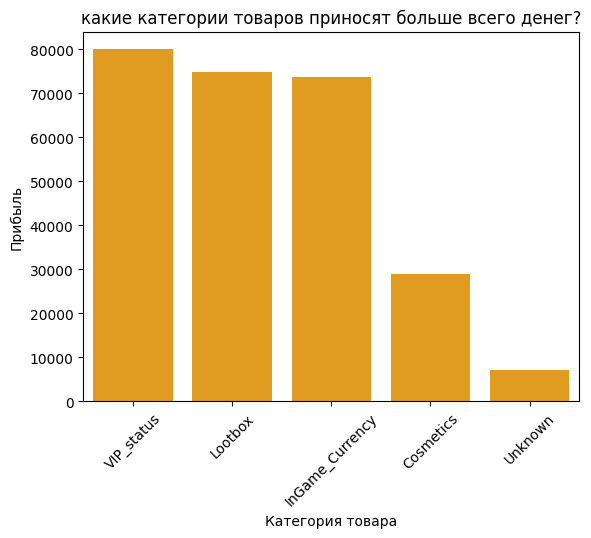

In [453]:
#Count Transaction Per User
CTPU = (
    donations.groupby('user_id').agg(
        count_transactions=('payment_id','count'),
        total_revenue=('amount_val','sum')
    )
.reset_index()
)
more_3_transactions = CTPU[CTPU['count_transactions'] > 3]
whale_revenue = more_3_transactions['total_revenue'].sum()
whale_revenue_pct =  (whale_revenue / revenue * 100).round(2)

category_revenue = (
    donations.groupby('item_category')['amount_val']
    .sum()
    .reset_index()
    .rename(columns={'amount_val': 'total_amount'})
    .sort_values(by='total_amount', ascending=False)
)

print(f'Процент от общей выручки сервера принесли эти «Киты»: {whale_revenue_pct}')

sns.barplot(
    data=category_revenue,
    x='item_category',
    y='total_amount',
    color='orange'
)
plt.xticks(rotation=45)
plt.title('какие категории товаров приносят больше всего денег?')
plt.xlabel('Категория товара')
plt.ylabel('Прибыль')
plt.show()

In [454]:
donaters = donations[donations['item_category'].isin(['Cosmetics', 'InGame_Currency', 'Lootbox', 'VIP_status'])]

users['is_donater'] = users['user_id'].isin(donations['user_id'].unique())

sessions = sessions.merge(users[['user_id', 'is_donater']])
sessions['time_session_min'] = (sessions['logout_time'] - sessions['login_time']).dt.total_seconds() / 60
sessions

pay_to_win = (
    sessions.groupby('is_donater')['time_session_min']
    .mean()
    .reset_index()
    .rename(columns={'time_session': 'mean_time_session'})
    .round(2)
)
print(f'Играет незначительно дольше за одну сессию:  не донатер,  на пол минуты')
pay_to_win

Играет незначительно дольше за одну сессию:  не донатер,  на пол минуты


,is_donater,time_session_min
0,False,44.10
1,True,43.65
